In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.neural_network import MLPRegressor   # ANN (Backpropagation)
from sklearn.svm import SVR                        # Support Vector Regression
from sklearn.tree import DecisionTreeRegressor     # Decision Tree


In [2]:

# ============================================================
# SECTION 2 — LOAD & PREPARE DATA
# ============================================================

FILE_PATH = "/kaggle/input/datasets/tungalavenkata/blue-main/blue_mountain_supercomputer_monthly_failures_proper.csv"

df = pd.read_csv(FILE_PATH)

print("Columns:", df.columns.tolist())

# Drop SMP column (machine ID, not a feature)
if "SMP" in df.columns:
    smp_ids = df["SMP"].astype(str).values
    df = df.drop(columns=["SMP"])
else:
    smp_ids = np.arange(len(df)).astype(str)

# Features = months 1–14, Target = month 15
feature_cols = df.columns[:-1]
target_col   = df.columns[-1]

X = df[feature_cols].values.astype(float)
y = df[target_col].values.astype(float)

print(f"\nFeatures : {list(feature_cols)}")
print(f"Target   : {target_col}")
print(f"y stats  → min={y.min():.1f}, max={y.max():.1f}, mean={y.mean():.2f}")


Columns: ['SMP', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']

Features : ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']
Target   : 15
y stats  → min=1.0, max=8.0, mean=2.48


In [3]:

# --- ANN: Backpropagation Neural Network ---
# Single hidden layer with 20 neurons, tanh activation
# Trained using backpropagation (LBFGS solver for small datasets)
ann_model = MLPRegressor(
    hidden_layer_sizes=(20,),    # 1 hidden layer, 20 neurons
    activation="tanh",           # tanh activation function
    solver="lbfgs",              # works better than adam on small datasets
    max_iter=2000,
    random_state=42
)

# --- SVM: Support Vector Regression ---
# RBF kernel to capture non-linear failure patterns
# C=100 allows more flexibility, epsilon=0.1 is the error margin tube
svr_model = SVR(
    kernel="rbf",     # Radial Basis Function kernel (handles non-linearity)
    C=100,            # Regularization — higher = less regularization
    epsilon=0.1,      # Tube width — predictions within epsilon have 0 loss
    gamma="scale"     # Kernel coefficient auto-scaled to features
)

# --- Decision Tree Regression ---
# Splits data on feature thresholds to minimize MSE at each node
# max_depth avoids overfitting on small datasets
dt_model = DecisionTreeRegressor(
    max_depth=5,          # limit tree depth to prevent overfitting
    min_samples_split=3,  # need at least 3 samples to split a node
    random_state=42
)

models = {
    "ANN (Backprop)"  : ann_model,
    "SVR"             : svr_model,
    "Decision Tree"   : dt_model,
}


In [4]:
# ============================================================
# SECTION 4 — 10-FOLD CROSS VALIDATION
# ============================================================

def run_benchmark(models, X, y, n_splits=10):
    """
    Runs 10-fold cross validation for each model.
    Applies StandardScaler inside each fold to avoid data leakage.

    Returns:
        results_df — DataFrame with RMSE, MAE, R2 per model
        all_preds  — dict of out-of-fold predictions per model
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results   = []
    all_preds = {}

    for name, model in models.items():
        fold_rmse, fold_mae, fold_r2 = [], [], []
        oof_preds = np.empty(len(y), dtype=float)

        for tr_idx, te_idx in kf.split(X):
            X_tr, X_te = X[tr_idx], X[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]

            # Fit scaler only on training fold (prevent data leakage)
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            model.fit(X_tr_s, y_tr)
            pred = model.predict(X_te_s)

            oof_preds[te_idx] = pred
            fold_rmse.append(np.sqrt(mean_squared_error(y_te, pred)))
            fold_mae.append(mean_absolute_error(y_te, pred))
            fold_r2.append(r2_score(y_te, pred))

        results.append({
            "Model" : name,
            "RMSE"  : round(np.mean(fold_rmse), 4),
            "MAE"   : round(np.mean(fold_mae), 4),
            "R2"    : round(np.mean(fold_r2), 4),
        })
        all_preds[name] = oof_preds
        print(f"[Done] {name} → RMSE: {np.mean(fold_rmse):.4f} | MAE: {np.mean(fold_mae):.4f}")

    results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
    return results_df, all_preds


results_df, all_preds = run_benchmark(models, X, y, n_splits=10)

print("\n========== BENCHMARK RESULTS (sorted by RMSE) ==========\n")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
print(f"\n✅ Best Model: {best_model_name}")


[Done] ANN (Backprop) → RMSE: 1.5788 | MAE: 1.3056
[Done] SVR → RMSE: 1.5341 | MAE: 1.2789
[Done] Decision Tree → RMSE: 1.1700 | MAE: 0.9191

========== BENCHMARK RESULTS (sorted by RMSE) ==========

         Model   RMSE    MAE      R2
 Decision Tree 1.1700 0.9191 -0.2394
           SVR 1.5341 1.2789 -0.8203
ANN (Backprop) 1.5788 1.3056 -1.4139

✅ Best Model: Decision Tree


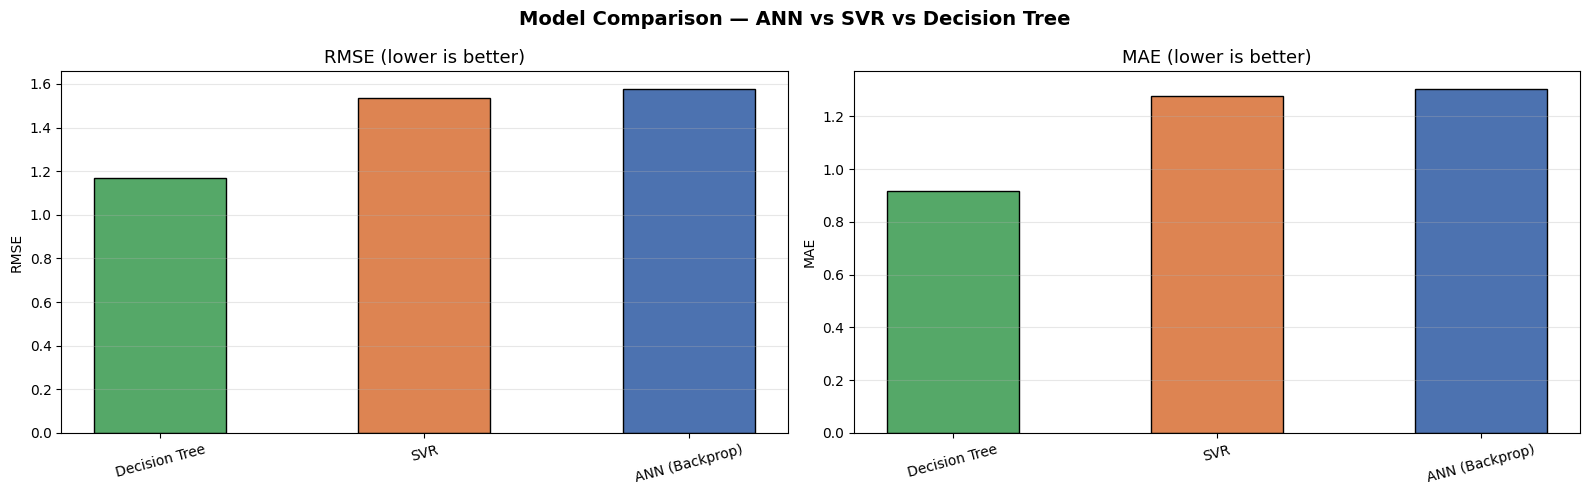

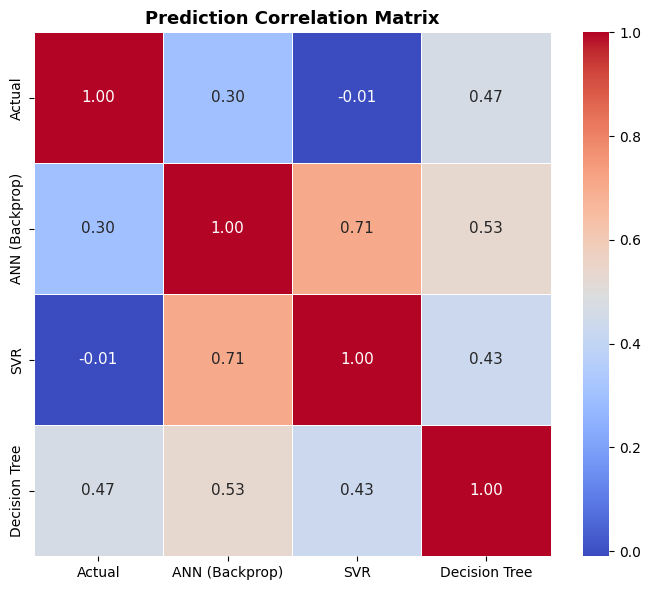

In [5]:

# ============================================================
# SECTION 5 — PLOTS
# ============================================================

colors = {"ANN (Backprop)": "#4C72B0", "SVR": "#DD8452", "Decision Tree": "#55A868"}

# --- Plot 1: RMSE & MAE Bar Chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = [colors[m] for m in results_df["Model"]]

axes[0].bar(results_df["Model"], results_df["RMSE"], color=bar_colors, edgecolor="black", width=0.5)
axes[0].set_title("RMSE (lower is better)", fontsize=13)
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(results_df["Model"], results_df["MAE"], color=bar_colors, edgecolor="black", width=0.5)
axes[1].set_title("MAE (lower is better)", fontsize=13)
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)



plt.suptitle("Model Comparison — ANN vs SVR vs Decision Tree", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()





# ---  Correlation Heatmap ---
pred_dict = {"Actual": y}
pred_dict.update(all_preds)

corr_matrix = pd.DataFrame(pred_dict).corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 11})
plt.title("Prediction Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()



In [6]:
# ============================================================
# SECTION 6 — PER MACHINE ERROR ANALYSIS (BEST MODEL)
# ============================================================

best_preds = all_preds[best_model_name]

per_machine_df = pd.DataFrame({
    "SMP"    : smp_ids,
    "Actual" : y,
    "Pred"   : best_preds.round(2),
    "AbsErr" : np.abs(y - best_preds).round(2)
}).sort_values("AbsErr", ascending=False).reset_index(drop=True)

print(f"\n========== PER-MACHINE ERROR — {best_model_name} ==========\n")
print("Top 10 worst predicted machines:\n")












print(per_machine_df.head(10).to_string(index=False))
print(f"\nMean Absolute Error across all machines: {per_machine_df['AbsErr'].mean():.4f}")


========== PER-MACHINE ERROR — Decision Tree ==========

Top 10 worst predicted machines:

SMP  Actual  Pred  AbsErr
 22     8.0  4.00    4.00
 11     1.0  4.50    3.50
  6     4.0  1.27    2.73
  1     5.0  2.62    2.38
 21     5.0  3.00    2.00
 37     2.0  4.00    2.00
 39     1.0  2.67    1.67
 17     3.0  1.47    1.53
 13     1.0  2.50    1.50
 38     3.0  1.60    1.40

Mean Absolute Error across all machines: 0.9208


In [7]:
# ============================================================
# SOFTWARE RELIABILITY — CLASSIFICATION BENCHMARK
# Models : Decision Tree, Bagging, SVM (SVC)
# Dataset: blue_mountain_supercomputer_monthly_failures_proper.csv
# Problem: Given failure counts for months 1–14,
#          classify month 15 as Low Risk (0) or High Risk (1)
# Threshold: failures <= 2 → Class 0 (Low Risk)
#            failures >= 3 → Class 1 (High Risk)
# ============================================================


# ============================================================
# SECTION 1 — IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC


In [8]:

# ============================================================
# SECTION 2 — LOAD & PREPARE DATA
# ============================================================

FILE_PATH = "/kaggle/input/datasets/tungalavenkata/blue-main/blue_mountain_supercomputer_monthly_failures_proper.csv"

df = pd.read_csv(FILE_PATH)

print("Columns:", df.columns.tolist())

# Drop SMP (machine ID, not a feature)
if "SMP" in df.columns:
    smp_ids = df["SMP"].astype(str).values
    df = df.drop(columns=["SMP"])
else:
    smp_ids = np.arange(len(df)).astype(str)

# Features = months 1–14, Target = month 15
feature_cols = df.columns[:-1]
target_col   = df.columns[-1]

X = df[feature_cols].values.astype(float)
y_raw = df[target_col].values.astype(float)

# ── Convert to binary classes using threshold = 2 (median) ──
# failures <= 2  →  Class 0 (Low Risk)
# failures >= 3  →  Class 1 (High Risk)
THRESHOLD = 2
y = (y_raw > THRESHOLD).astype(int)

print(f"\nFeatures  : {list(feature_cols)}")
print(f"Target    : {target_col}")
print(f"Threshold : <= {THRESHOLD} → Class 0 (Low Risk) | > {THRESHOLD} → Class 1 (High Risk)")
print(f"\nClass distribution:")
print(f"  Class 0 (Low Risk)  : {(y == 0).sum()} machines ({(y == 0).mean()*100:.1f}%)")
print(f"  Class 1 (High Risk) : {(y == 1).sum()} machines ({(y == 1).mean()*100:.1f}%)")



Columns: ['SMP', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']

Features  : ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']
Target    : 15
Threshold : <= 2 → Class 0 (Low Risk) | > 2 → Class 1 (High Risk)

Class distribution:
  Class 0 (Low Risk)  : 30 machines (62.5%)
  Class 1 (High Risk) : 18 machines (37.5%)


In [9]:
# --- Decision Tree Classifier ---
# class_weight="balanced" adjusts for class imbalance (30 vs 18)
# max_depth=4 prevents overfitting on small dataset
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=3,
    class_weight="balanced",
    random_state=42
)

# --- Bagging Classifier ---
# Builds 50 Decision Trees on random subsamples and majority votes
# Reduces variance compared to a single Decision Tree
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=42),
    n_estimators=50,
    random_state=42
)

# --- SVM Classifier (SVC) ---
# RBF kernel for non-linear decision boundary
# class_weight="balanced" handles imbalance
# probability=True enables predict_proba for future use
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

# Wrap SVM in a Pipeline with StandardScaler
# (DT and Bagging don't need scaling, but SVM does)
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", svm_model)
])

models = {
    "Decision Tree" : dt_model,
    "Bagging"       : bagging_model,
    "SVM (SVC)"     : svm_pipeline,
}

In [10]:

# ============================================================
# SECTION 4 — STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================
# Using StratifiedKFold to ensure both classes appear in every fold
# n_splits=5 because dataset has only 48 samples

def run_classification_benchmark(models, X, y, n_splits=5):
    """
    Stratified K-Fold cross validation for all classifiers.
    Scales features inside each fold to prevent data leakage.
    SVM already has scaler in its Pipeline.

    Returns:
        results_df — DataFrame with Accuracy, F1 per model
        all_preds  — dict of out-of-fold predictions per model
    """
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    all_preds = {}

    for name, model in models.items():
        fold_acc, fold_f1 = [], []
        oof_preds = np.empty(len(y), dtype=int)

        for tr_idx, te_idx in skf.split(X, y):
            X_tr, X_te = X[tr_idx], X[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]

            # Scale only for non-pipeline models (DT, Bagging)
            if not isinstance(model, Pipeline):
                scaler = StandardScaler()
                X_tr = scaler.fit_transform(X_tr)
                X_te = scaler.transform(X_te)

            model.fit(X_tr, y_tr)
            pred = model.predict(X_te)

            oof_preds[te_idx] = pred
            fold_acc.append(accuracy_score(y_te, pred))
            fold_f1.append(f1_score(y_te, pred, average="weighted", zero_division=0))

        results.append({
            "Model"    : name,
            "Accuracy" : round(np.mean(fold_acc), 4),
            "F1 Score" : round(np.mean(fold_f1), 4),
        })
        all_preds[name] = oof_preds
        print(f"[Done] {name:15s} → Accuracy: {np.mean(fold_acc):.4f} | F1: {np.mean(fold_f1):.4f}")

    results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
    return results_df, all_preds


results_df, all_preds = run_classification_benchmark(models, X, y, n_splits=5)

print("\n========== CLASSIFICATION RESULTS (sorted by F1 Score) ==========\n")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
print(f"\n✅ Best Model: {best_model_name}")

    

[Done] Decision Tree   → Accuracy: 0.6911 | F1: 0.6736
[Done] Bagging         → Accuracy: 0.6933 | F1: 0.6688
[Done] SVM (SVC)       → Accuracy: 0.3556 | F1: 0.3556

========== CLASSIFICATION RESULTS (sorted by F1 Score) ==========

        Model  Accuracy  F1 Score
Decision Tree    0.6911    0.6736
      Bagging    0.6933    0.6688
    SVM (SVC)    0.3556    0.3556

✅ Best Model: Decision Tree


In [11]:

# ============================================================
# SECTION 6 — CLASSIFICATION REPORT (BEST MODEL)
# ============================================================

print(f"\n========== CLASSIFICATION REPORT — {best_model_name} ==========\n")
print(classification_report(
    y,
    all_preds[best_model_name],
    target_names=["Low Risk (0)", "High Risk (1)"]
))





========== CLASSIFICATION REPORT — Decision Tree ==========

               precision    recall  f1-score   support

 Low Risk (0)       0.73      0.80      0.76        30
High Risk (1)       0.60      0.50      0.55        18

     accuracy                           0.69        48
    macro avg       0.66      0.65      0.65        48
 weighted avg       0.68      0.69      0.68        48

